# MDM on retail sales: structure learning and group analysis

End-to-end tour of the mdmp public API on daily retail SKU sales.

One `MDM` models a single multivariate series. Group tools need a cohort with
equal node count `N`:

- **VTS / IS** — prefer shared node meaning across subjects (monthly panels)
- **GS** — only needs equal `N` (food groups or lag-embedded products)

This notebook is the canonical full example for the library.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve this notebook's directory even when the kernel cwd is elsewhere
# (otherwise `import mdmp` may pick up another install without local fixes).
_vsc = globals().get("__vsc_ipynb_file__")
if _vsc:
    DEMO = Path(_vsc).resolve().parent
elif (Path.cwd() / "retail_helpers.py").exists():
    DEMO = Path.cwd().resolve()
elif (Path.cwd() / "examples" / "notebooks" / "retail_helpers.py").exists():
    DEMO = (Path.cwd() / "examples" / "notebooks").resolve()
elif (Path.cwd() / "notebooks" / "retail_helpers.py").exists():  # legacy
    DEMO = (Path.cwd() / "notebooks").resolve()
else:
    DEMO = Path.cwd().resolve()

# Project root: examples/notebooks -> ../..
PKG_ROOT = DEMO.parent.parent if DEMO.parent.name == "examples" else DEMO.parent
sys.path.insert(0, str(PKG_ROOT))
sys.path.insert(0, str(DEMO))

from retail_helpers import (
    C3_LABELS,
    C4_LABELS,
    DAG_LABELS,
    SKU_DAG_LABELS,
    aggregate_by_level,
    cohort_summary,
    food_group_subjects,
    monthly_subjects,
    one_sku_per_type,
    order_skus_by_level,
    parse_retail_dataset,
    product_lag_subjects,
)

from mdmp import (
    MDM,
    aggregate_individual_structures,
    compute_mdm_distance,
    compute_vts,
    detect_anomalies,
    fit_individual_structures,
    nearest_neighbours,
    plot_anomalies,
    plot_arcs,
    plot_dag,
    plot_group_embedding,
    plot_marginal,
    plot_stream,
    suggest_clusters,
)
import mdmp as _mdmp

NBF = 15
NBF_MONTHLY = 10  # T per month is ~28–31
CI_LEVEL = 0.95
plt.rcParams["figure.figsize"] = (10, 5)
print("notebooks:", DEMO)
print("mdmp root:", PKG_ROOT)
print("mdmp file:", _mdmp.__file__)


C:\Users\Maods\.pyenv\pyenv-win\versions\3.10.4\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


demo: D:\dev\phd\articles\mdmp-package\mdmp\notebooks\retail-demo
mdmp root: D:\dev\phd\articles\mdmp-package\mdmp
mdmp file: D:\dev\phd\articles\mdmp-package\mdmp\mdmp\__init__.py


## 1. Load & hierarchy

CSV has no header: three hierarchy rows (product type / line / item), then 180 daily rows.
Node names are `Line|Item`.

In [2]:
sales, hierarchy = parse_retail_dataset()
skus = [c for c in sales.columns if c != "Time"]
print(sales.shape, f"{sales['Time'].min().date()} -> {sales['Time'].max().date()}")
print(f"{len(skus)} SKUs | C3 types: {hierarchy['type'].nunique()} | C4 lines: {hierarchy['line'].nunique()}")
hierarchy

(180, 16) 2024-01-01 -> 2024-06-28
15 SKUs | C3 types: 7 | C4 lines: 12


,type,line,item
Cerveja|Lata,Alcoolicas,Cerveja,Lata
Cerveja|Latao,Alcoolicas,Cerveja,Latao
Cerveja|Retornavel 250ml,Alcoolicas,Cerveja,Retornavel 250ml
Arroz|5kg,Cereais Básicos,Arroz,5kg
Feijao|1kg,Cereais Básicos,Feijao,1kg
Pao|Forma,Padaria,Pao,Forma
Oleo_Soja|1L,Conservas,Oleo_Soja,1L
Molho_Tomate|250g,Conservas,Molho_Tomate,250g
Leite|Integral,Leite,Leite,Integral
Iogurte|Natural,Leite,Iogurte,Natural


## 2. Product MDM (15 SKUs)

Fit one MDM on the full product panel. Graphviz-style DAG uses short English labels.

In [3]:
sku_order = hierarchy.sort_values(["type", "line", "item"]).index.tolist()
panel = sales.loc[:, sku_order].copy()
panel.index = sales["Time"]

product_mdm = MDM(panel, method="hc", nbf=NBF, verbose=False, n_jobs=-1)
print("edges:", int(np.sum(product_mdm.adj_mat)))
print("DF_hat:", np.round(product_mdm.DF["DF_hat"], 3))

edges: 24
DF_hat: [0.5  1.   1.   1.   0.98 0.98 0.97 0.98 0.97 1.   0.98 1.   0.97 0.88
 0.5 ]


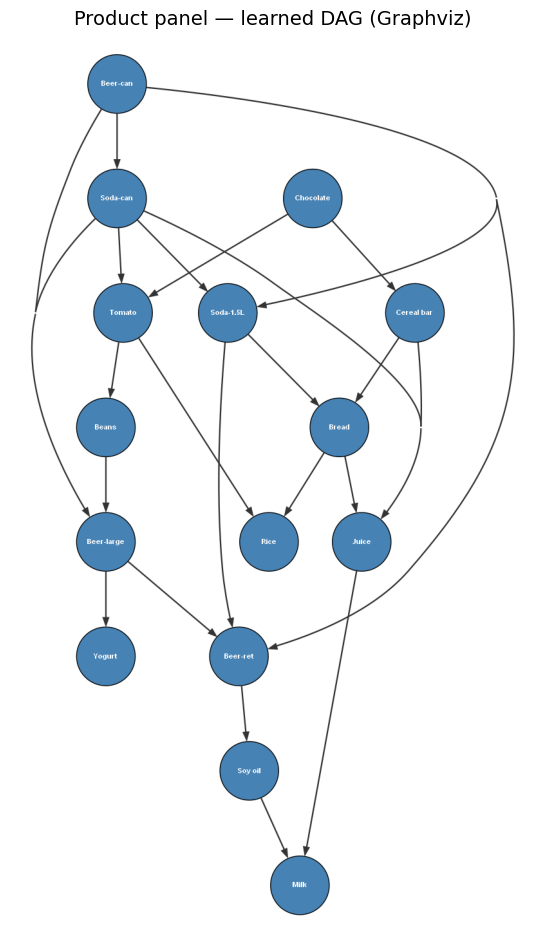

dynamics child: Cerveja|Latao | n_parents: 3


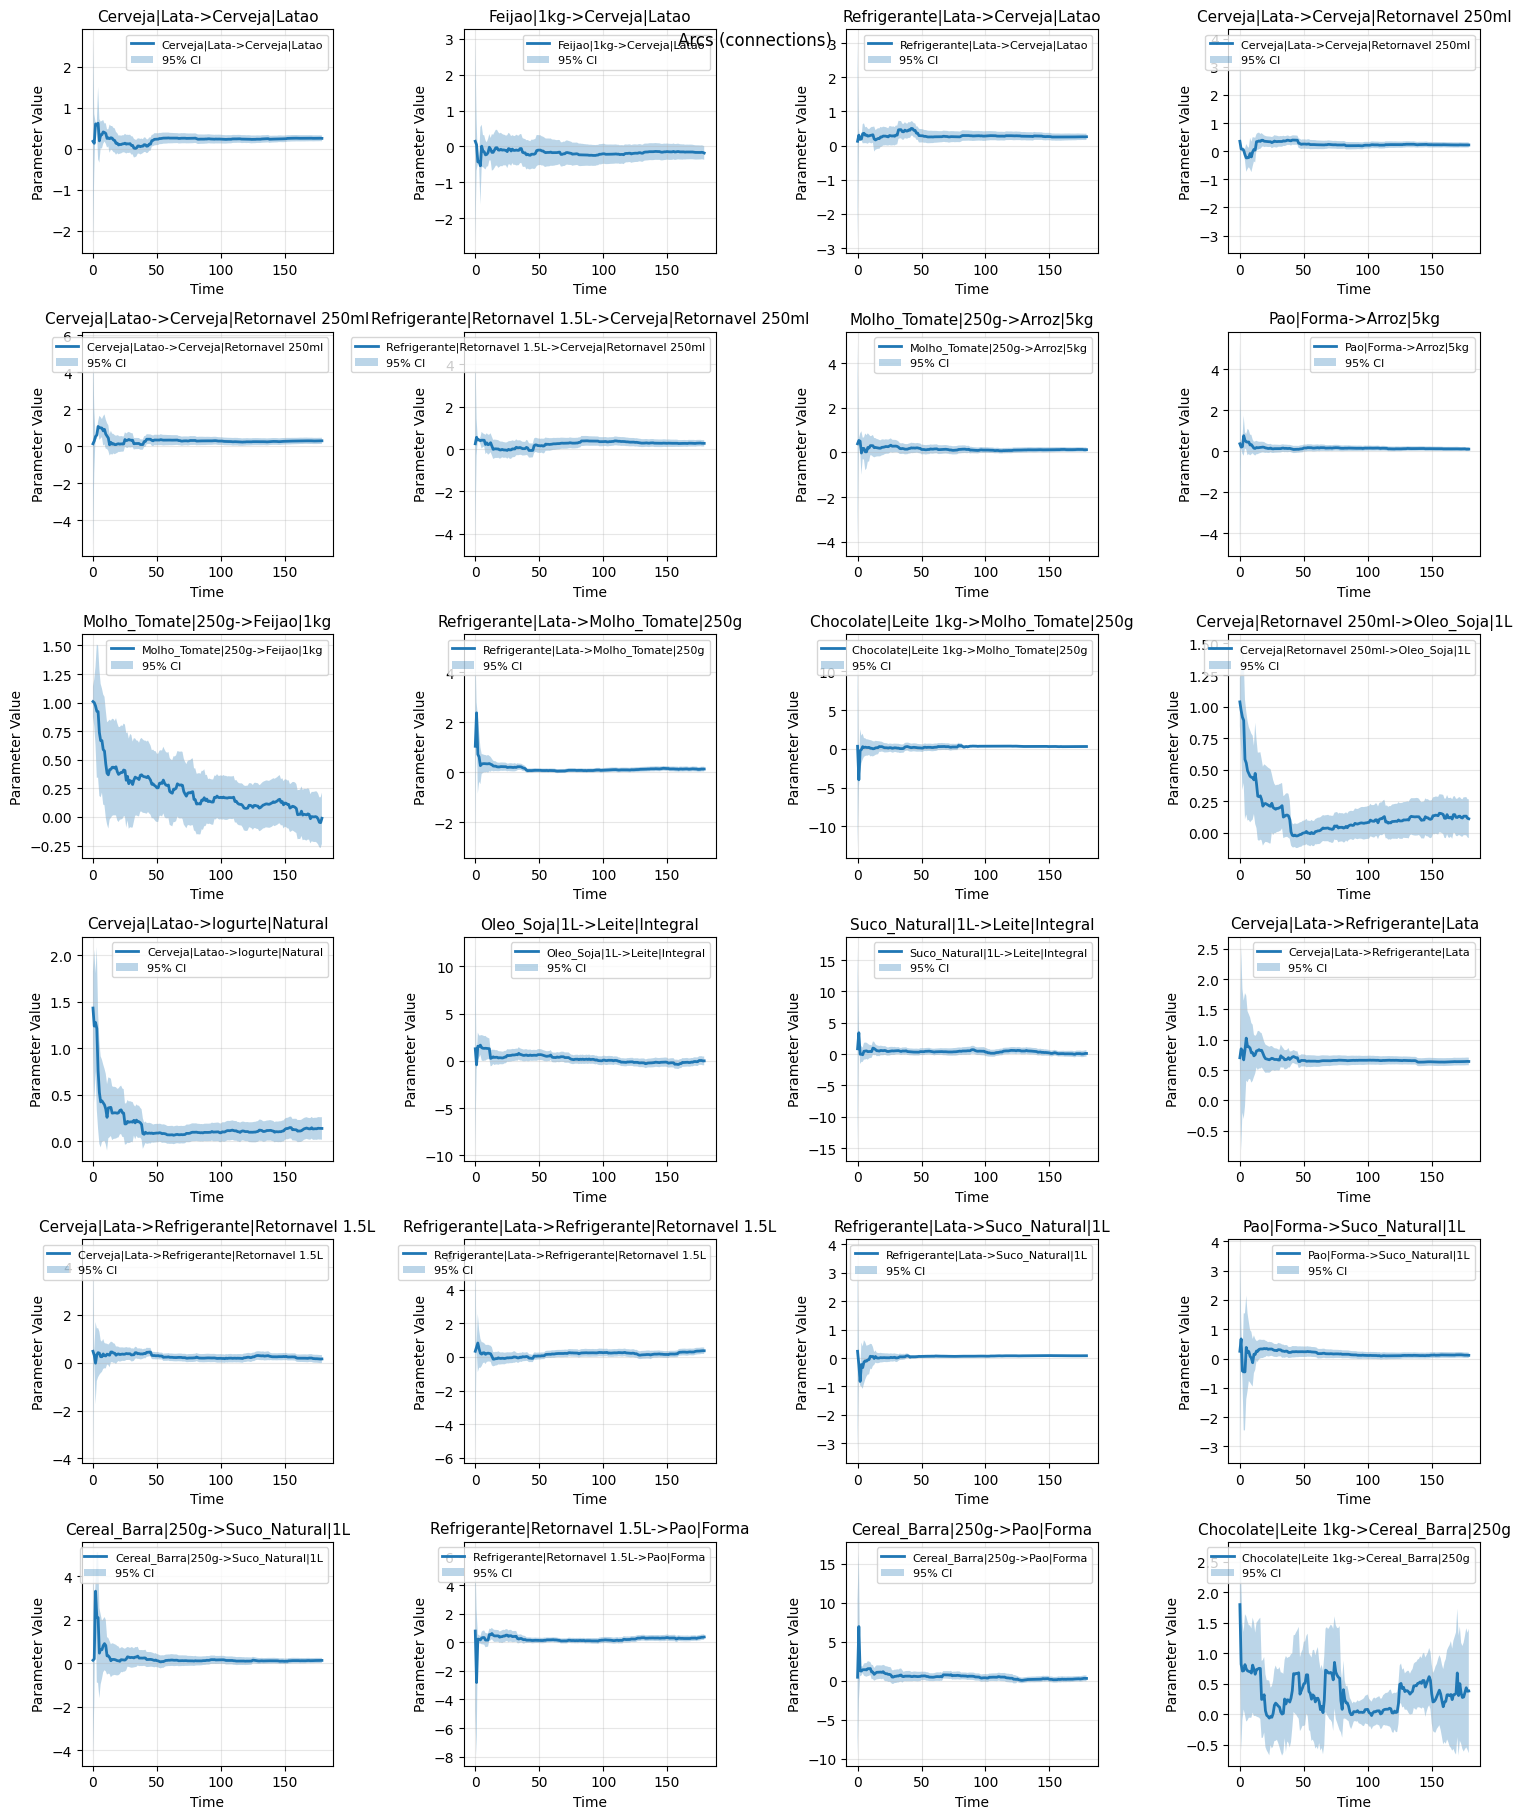

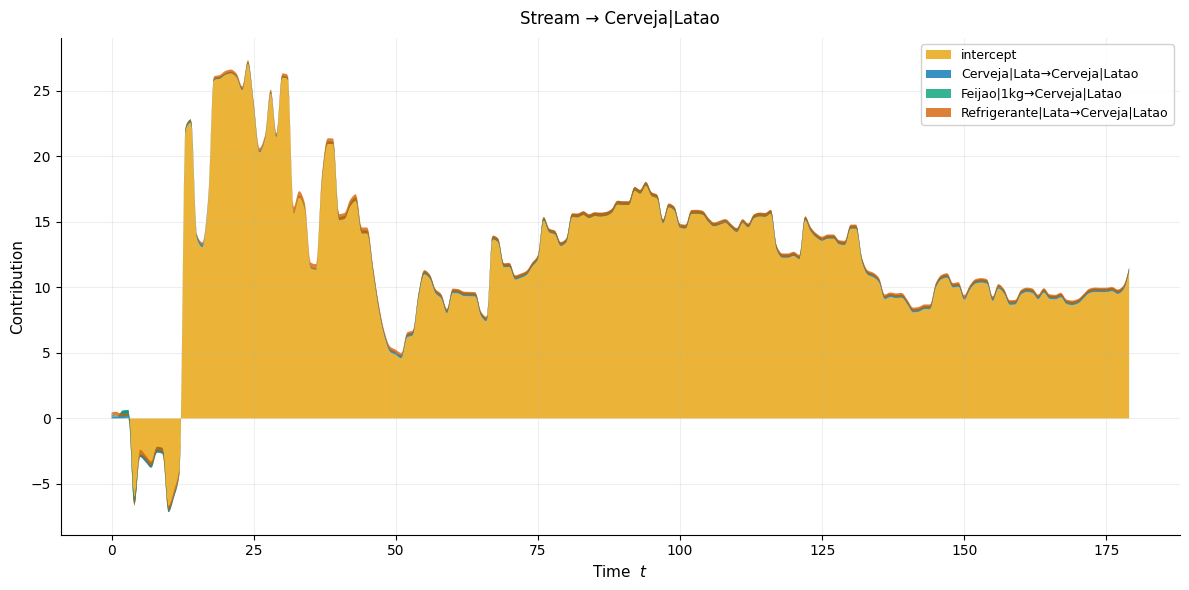

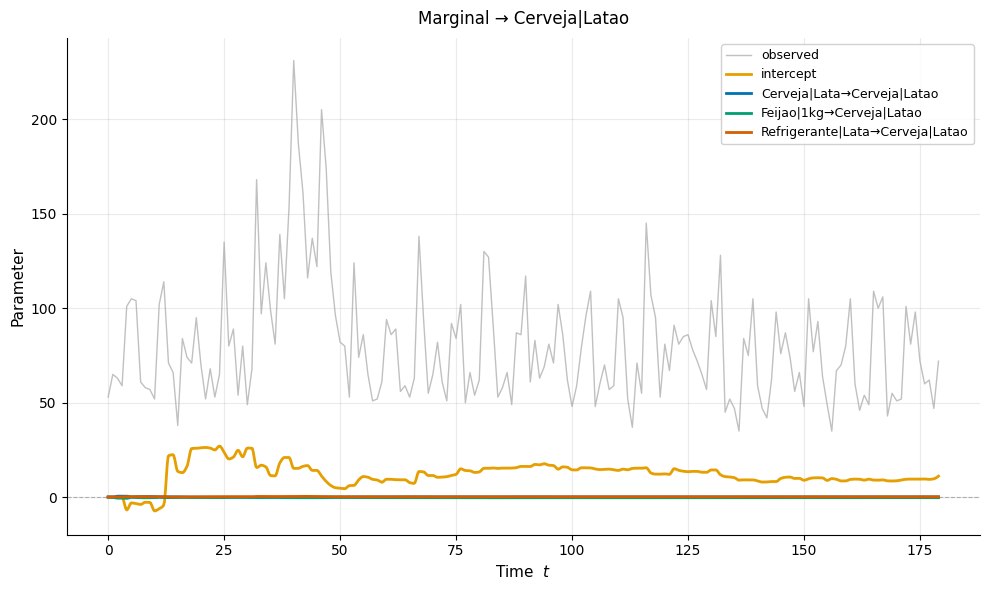

In [4]:
short_labels = [SKU_DAG_LABELS.get(s, s) for s in sku_order]

fig = plot_dag(
    product_mdm,
    node_labels=short_labels,
    style="graphviz",
    title="Product panel — learned DAG (Graphviz)",
)
plt.show()

adj = np.asarray(product_mdm.adj_mat)
parents_per_child = adj.sum(axis=0)
child_idx = int(np.argmax(parents_per_child)) if parents_per_child.max() > 0 else 0
child_name = sku_order[child_idx]
print("dynamics child:", child_name, "| n_parents:", int(parents_per_child[child_idx]))

plot_arcs(product_mdm, plot_type="connections")
plt.suptitle("Arcs (connections)")
plt.show()

plot_stream(product_mdm, child_node=child_idx, title=f"Stream → {child_name}")
plt.show()

plot_marginal(product_mdm, target_node=child_idx, title=f"Marginal → {child_name}")
plt.show()


## 3. Anomalies by C3 and C4

Anomalies use the **product** MDM (not aggregated). Panels are only **reordered** so SKUs
from the same C3 Product Line or C4 Product Type sit together.

total anomaly flags: 128 / 2700
                          n_anomalies
node                                 
Cerveja|Retornavel 250ml           14
Cereal_Barra|250g                  13
Suco_Natural|1L                    12
Chocolate|Leite 1kg                11
Cerveja|Latao                      10
Refrigerante|Lata                  10
Pao|Forma                           8
Cerveja|Lata                        7
Feijao|1kg                          7
Molho_Tomate|250g                   7


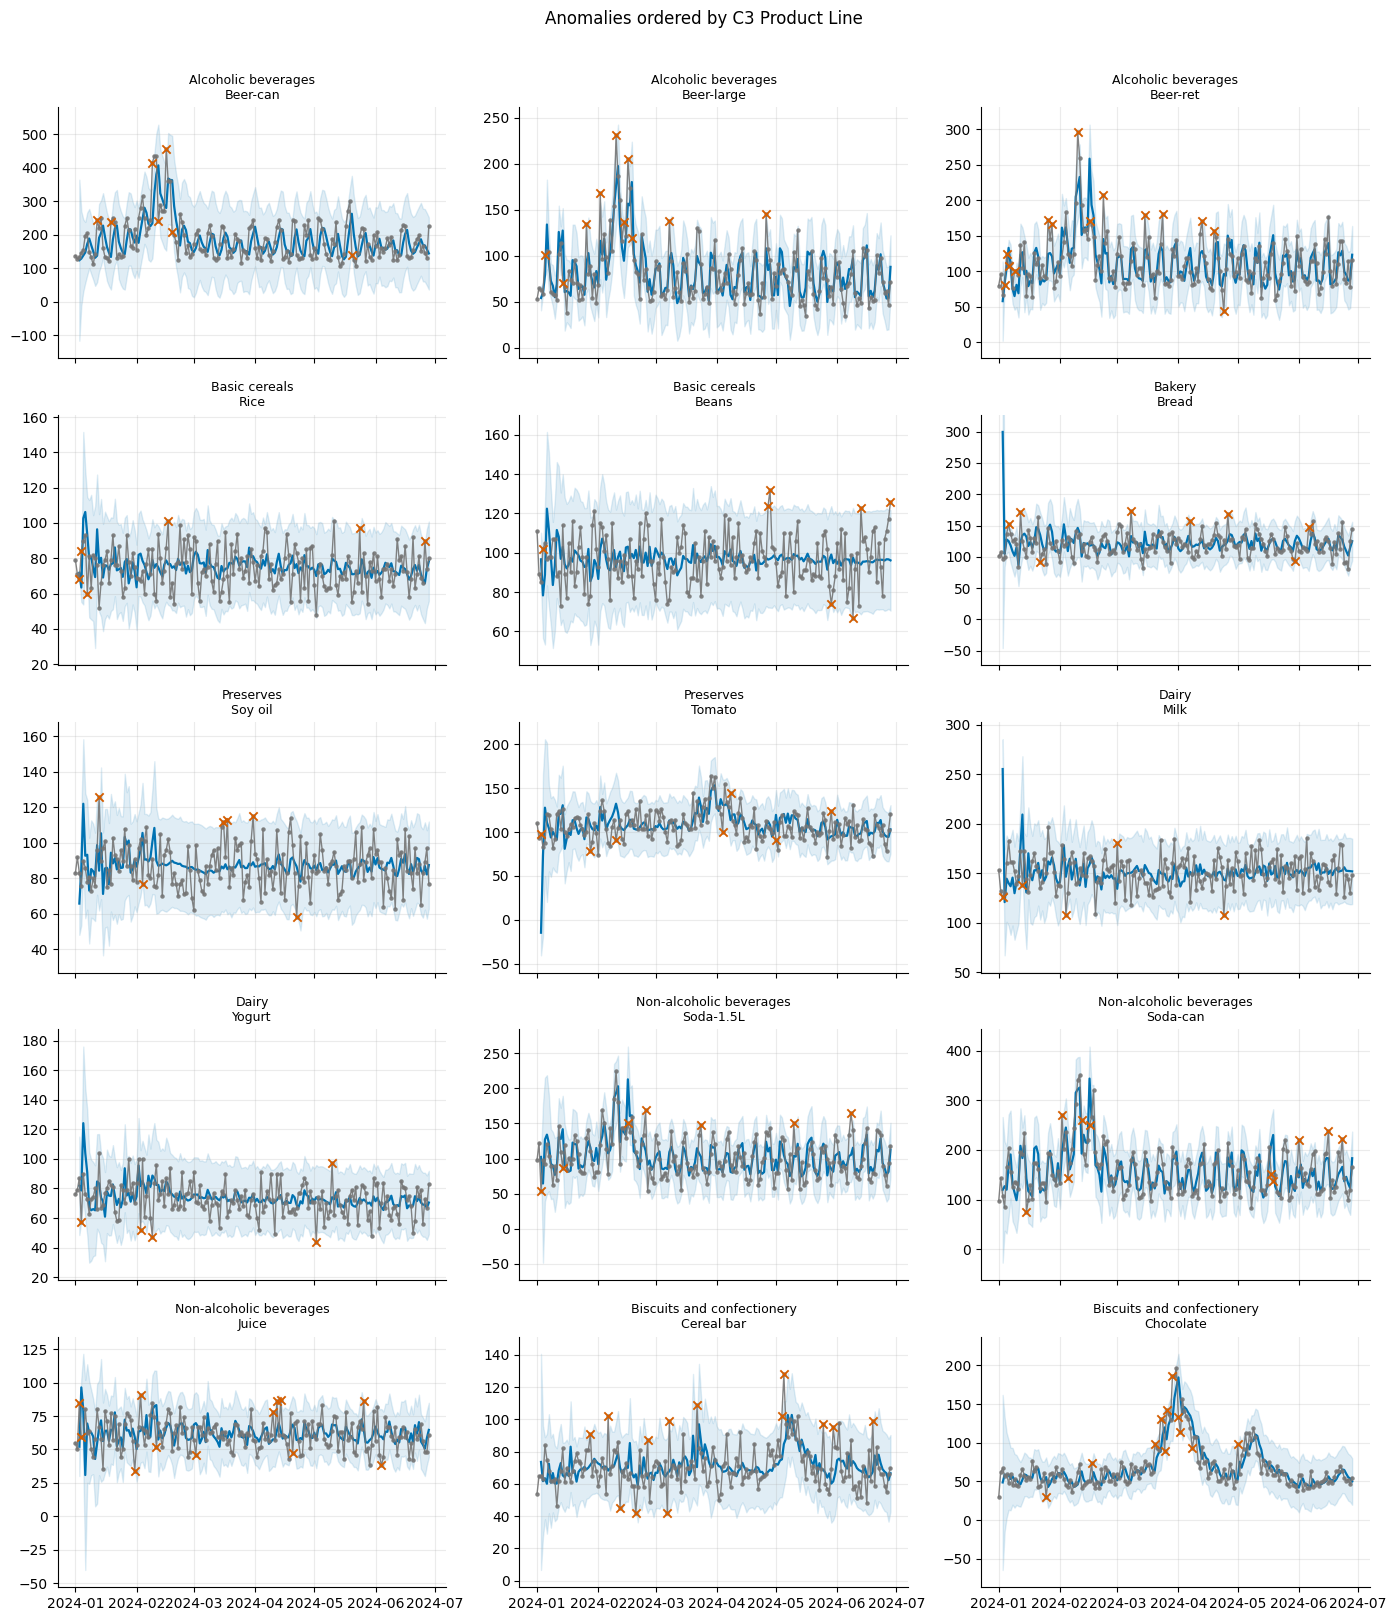

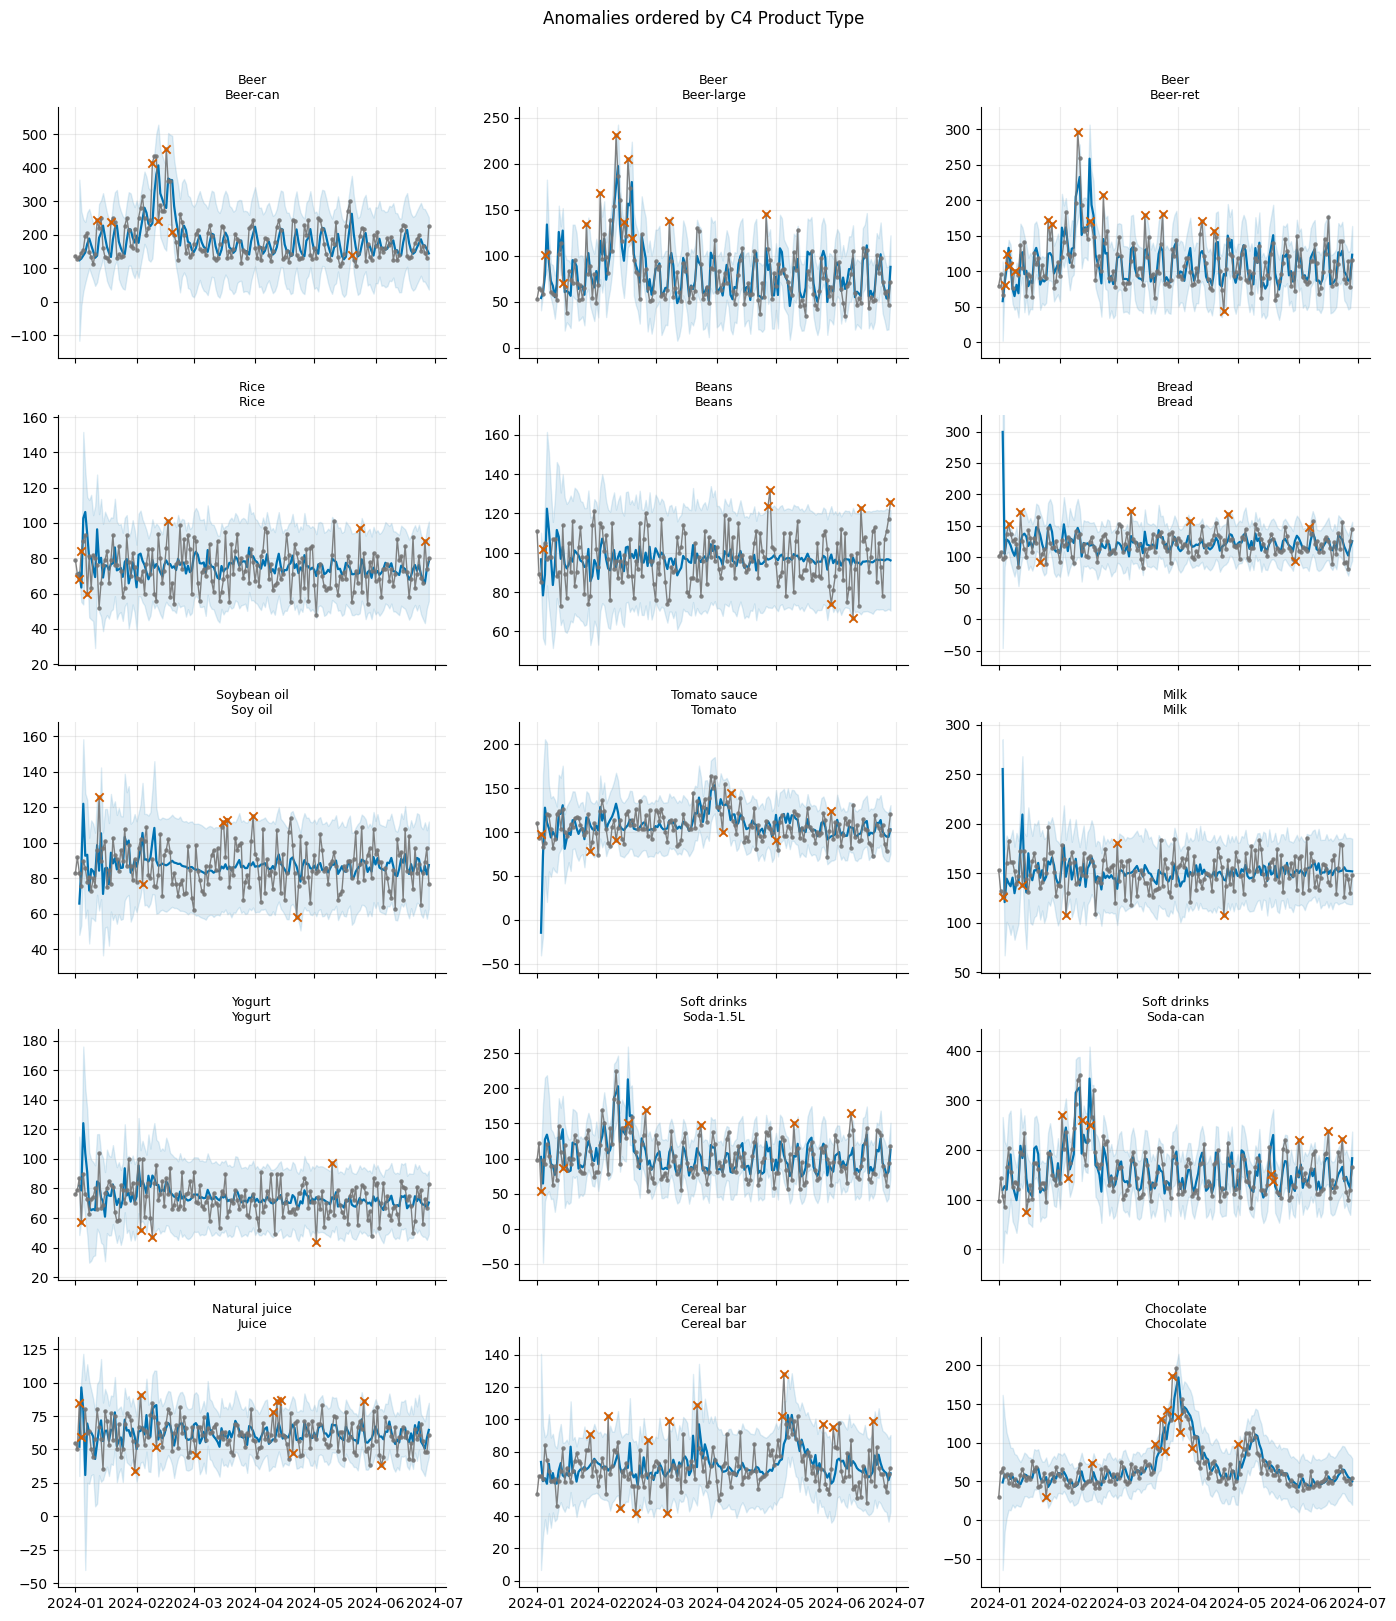

In [5]:
anom = detect_anomalies(
    product_mdm,
    ci_level=CI_LEVEL,
    series=None,
    output="dataframe",
    time_index=list(panel.index),
)
counts = (
    anom.groupby("node")["is_anomaly"]
    .sum()
    .astype(int)
    .rename("n_anomalies")
    .sort_values(ascending=False)
)
print(f"total anomaly flags: {int(anom['is_anomaly'].sum())} / {len(anom)}")
print(counts.head(10).to_frame())


def plot_anomaly_grid(level_key: str, title: str) -> None:
    ordered = order_skus_by_level(hierarchy, level_key)
    n_sku = len(ordered)
    ncols = 3
    nrows = int(np.ceil(n_sku / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), sharex=True)
    axes = np.atleast_1d(axes).ravel()
    col = "type" if level_key == "type" else "line"
    label_map = C3_LABELS if level_key == "type" else C4_LABELS
    for ax, sku in zip(axes, ordered):
        group = hierarchy.loc[sku, col]
        group_en = label_map.get(group, group)
        plot_anomalies(
            product_mdm,
            series=sku,
            ci_level=CI_LEVEL,
            ax=ax,
            time_index=list(panel.index),
        )
        ax.set_title(f"{group_en}\n{SKU_DAG_LABELS.get(sku, sku)}", fontsize=9)
    for ax in axes[n_sku:]:
        ax.set_visible(False)
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    plt.show()


plot_anomaly_grid("type", "Anomalies ordered by C3 Product Line")
plot_anomaly_grid("line", "Anomalies ordered by C4 Product Type")

## 4. Aggregated C3 / C4 DAGs

Sum SKU sales within each hierarchy level, then fit a separate MDM on the aggregated
multivariate series (7 C3 nodes, 12 C4 nodes).

C3: (180, 7) ['Alcoholic beverages', 'Basic cereals', 'Bakery', 'Preserves', 'Dairy', 'Non-alcoholic beverages', 'Biscuits and confectionery']
C4: (180, 12) ['Beer', 'Rice', 'Beans', 'Bread', 'Soybean oil', 'Tomato sauce', 'Milk', 'Yogurt', 'Soft drinks', 'Natural juice', 'Cereal bar', 'Chocolate']


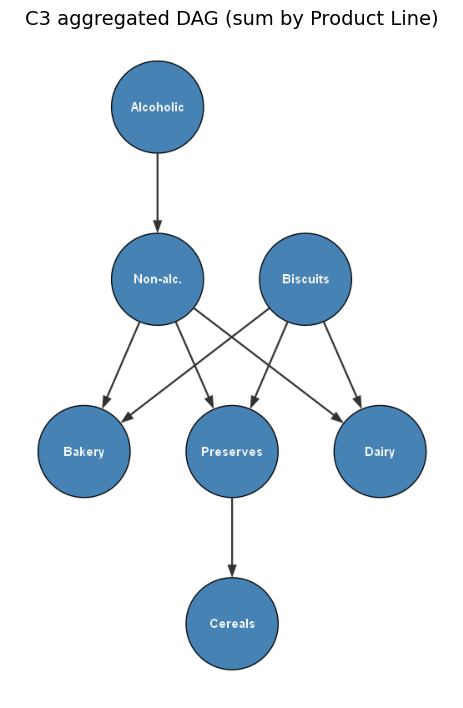

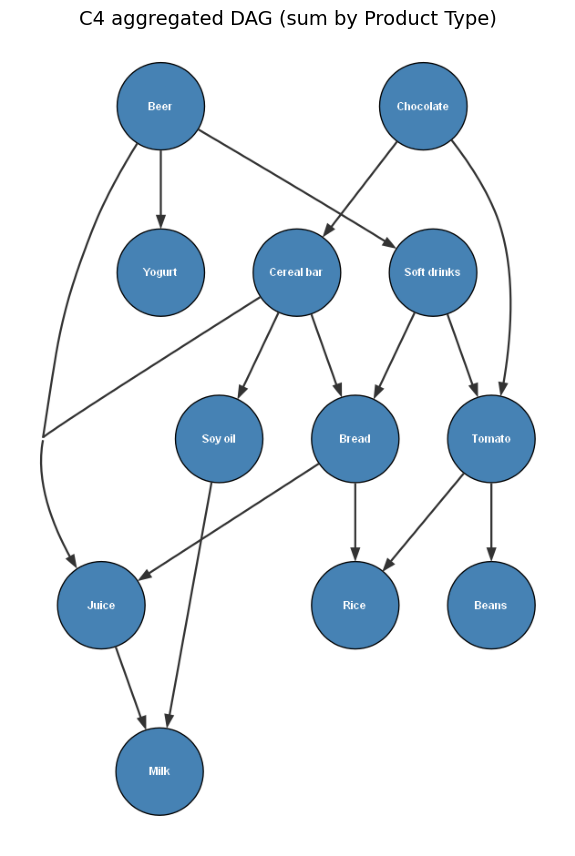

In [6]:
c3_data = aggregate_by_level(sales, hierarchy, "type")
c4_data = aggregate_by_level(sales, hierarchy, "line")
print("C3:", c3_data.shape, list(c3_data.columns))
print("C4:", c4_data.shape, list(c4_data.columns))

c3_mdm = MDM(c3_data, method="hc", nbf=NBF, verbose=False, n_jobs=-1)
c3_short = [DAG_LABELS.get(c, c) for c in c3_data.columns]
fig = plot_dag(
    c3_mdm,
    node_labels=c3_short,
    style="graphviz",
    title="C3 aggregated DAG (sum by Product Line)",
)
plt.show()

c4_mdm = MDM(c4_data, method="hc", nbf=NBF, verbose=False, n_jobs=-1)
c4_short = [DAG_LABELS.get(c, c) for c in c4_data.columns]
fig = plot_dag(
    c4_mdm,
    node_labels=c4_short,
    style="graphviz",
    title="C4 aggregated DAG (sum by Product Type)",
)
plt.show()


## 5. Monthly cohort for IS / VTS (shared nodes)

Treat each calendar month as a subject. Nodes are the **same** 7 SKUs across months
(one SKU per C3 type), so edges keep a fixed semantic meaning — required for
interpretable **IS** and **VTS**. Use `nbf=10` because each month has only ~28–31 days.

In [7]:
monthly_nodes = one_sku_per_type(hierarchy)
monthly_labels = [SKU_DAG_LABELS.get(s, s) for s in monthly_nodes]
print("monthly nodes (1 per C3 type):")
for sku, lab in zip(monthly_nodes, monthly_labels):
    print(f"  {lab:12s}  {sku}  [{hierarchy.loc[sku, 'type']}]")

subjects_m, subject_ids_m, node_names_m = monthly_subjects(
    sales, node_names=monthly_nodes
)
summary_m = cohort_summary(subjects_m, subject_ids_m, node_names_m)
print(summary_m)

monthly nodes (1 per C3 type):
  Beer-can      Cerveja|Lata  [Alcoolicas]
  Rice          Arroz|5kg  [Cereais Básicos]
  Bread         Pao|Forma  [Padaria]
  Soy oil       Oleo_Soja|1L  [Conservas]
  Milk          Leite|Integral  [Leite]
  Soda-1.5L     Refrigerante|Retornavel 1.5L  [Não-alcoólicas]
  Cereal bar    Cereal_Barra|250g  [biscoitos, bomboniere]
{'n_subjects': 6, 'n_nodes': 7, 'node_names': ['Cerveja|Lata', 'Arroz|5kg', 'Pao|Forma', 'Oleo_Soja|1L', 'Leite|Integral', 'Refrigerante|Retornavel 1.5L', 'Cereal_Barra|250g'], 'subject_ids': ['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06'], 'T_per_subject': [31, 29, 31, 30, 31, 28], 'T_min': 28, 'T_max': 31, 'shapes': [(31, 7), (29, 7), (31, 7), (30, 7), (31, 7), (28, 7)]}


## 6. Fit MDM individually → VTS → IS

`fit_individual_structures` fits one MDM per month. Then:

- **VTS** averages the monthly panels and fits MDM on the representative series
- **IS** votes the six adjacency matrices into a consensus DAG

edges per month: {'2024-01': 8, '2024-02': 8, '2024-03': 7, '2024-04': 5, '2024-05': 7, '2024-06': 7}


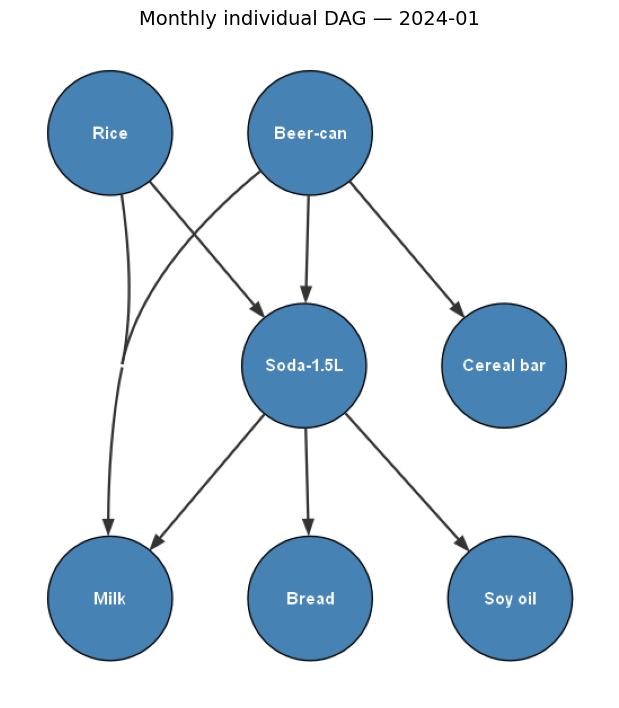

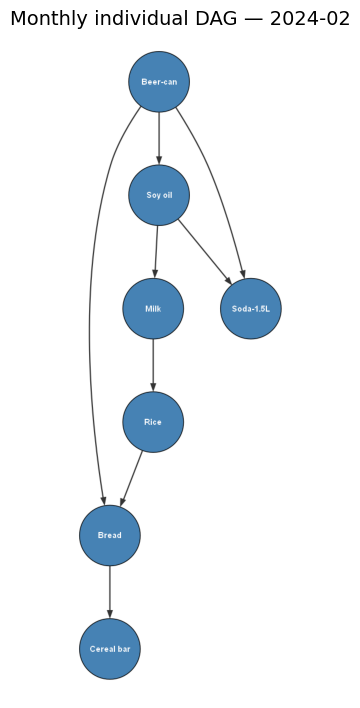

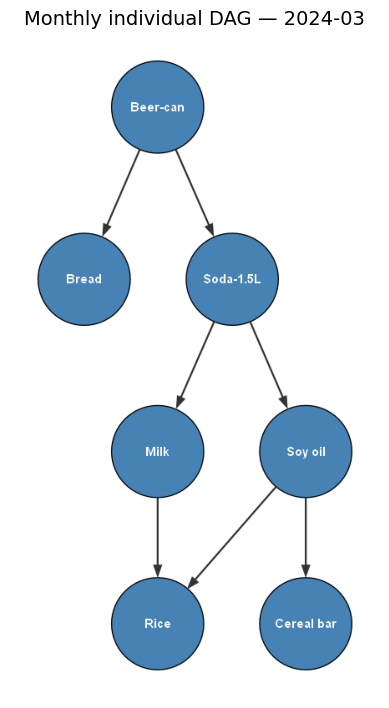

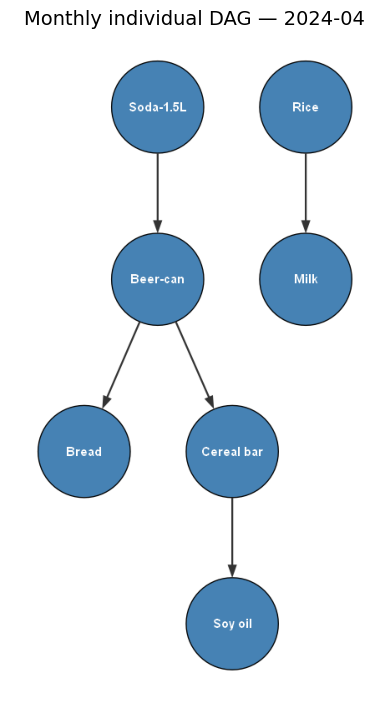

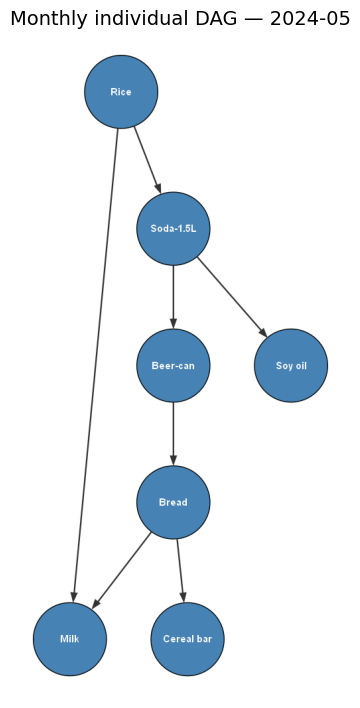

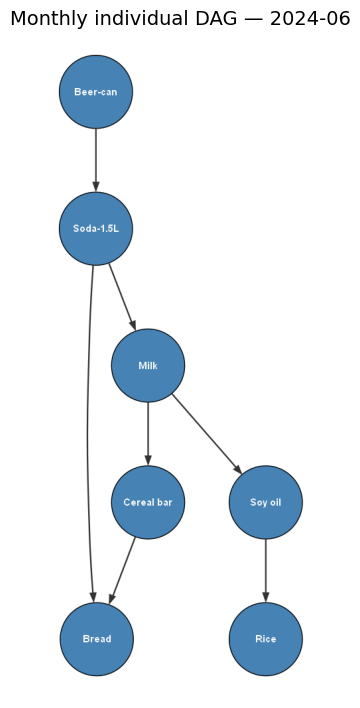

In [8]:
individuals_m = fit_individual_structures(
    subjects_m,
    method="hc",
    nbf=NBF_MONTHLY,
    node_names=monthly_labels,
    subject_ids=subject_ids_m,
    n_jobs=-1,
    verbose=False,
)
edge_counts = {
    sid: int(np.sum(m.adj_mat)) for sid, m in zip(subject_ids_m, individuals_m)
}
print("edges per month:", edge_counts)

for m, sid in zip(individuals_m, subject_ids_m):
    plot_dag(
        m,
        node_labels=monthly_labels,
        style="graphviz",
        title=f"Monthly individual DAG — {sid}",
    )
    plt.show()


VTS shape: (28, 7) | method: mean | S: 6


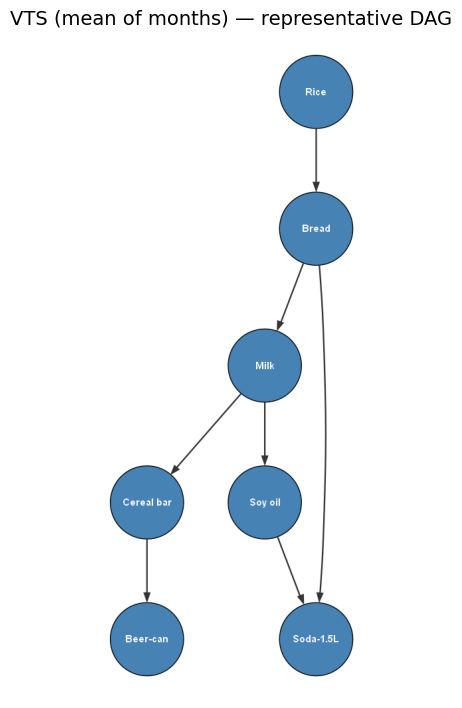

In [9]:
vts = compute_vts(subjects_m, method="mean")
print("VTS shape:", vts.vts_data.shape, "| method:", vts.method, "| S:", vts.n_subjects)

vts_df = pd.DataFrame(vts.vts_data, columns=monthly_labels)
vts_mdm = MDM(vts_df, method="hc", nbf=NBF_MONTHLY, verbose=False, n_jobs=-1)

fig = plot_dag(
    vts_mdm,
    node_labels=monthly_labels,
    style="graphviz",
    title="VTS (mean of months) — representative DAG",
)
plt.show()


consensus edges: 2


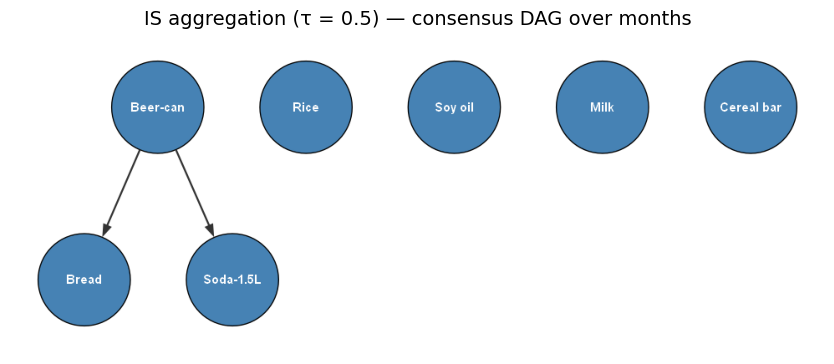

In [10]:
is_view = aggregate_individual_structures(
    [m.adj_mat for m in individuals_m],
    tau=0.5,
    node_names=monthly_labels,
)
print("consensus edges:", int(np.sum(is_view.adj_mat)))

fig = plot_dag(
    is_view,
    node_labels=monthly_labels,
    style="graphviz",
    title="IS aggregation (τ = 0.5) — consensus DAG over months",
)
plt.show()


## 7. GS — food groups (`food_N3`)

Five food-group subjects, each with N=3 generic slots (`SKU1..SKU3`). Node meaning
differs across groups; GS only needs equal `N` for pairwise structure distance.

In [11]:
subjects_f, subject_ids_f, node_names_f, membership = food_group_subjects(sales)
print(cohort_summary(subjects_f, subject_ids_f, node_names_f))
pd.DataFrame(membership, index=node_names_f).T

{'n_subjects': 5, 'n_nodes': 3, 'node_names': ['SKU1', 'SKU2', 'SKU3'], 'subject_ids': ['Alcoolicas', 'Nao-alcoolicas', 'Cereais_Padaria', 'Leite_Conservas', 'Conservas_Biscoitos'], 'T_per_subject': [180, 180, 180, 180, 180], 'T_min': 180, 'T_max': 180, 'shapes': [(180, 3), (180, 3), (180, 3), (180, 3), (180, 3)]}


,SKU1,SKU2,SKU3
Alcoolicas,Cerveja|Lata,Cerveja|Latao,Cerveja|Retornavel 250ml
Nao-alcoolicas,Refrigerante|Retornavel 1.5L,Refrigerante|Lata,Suco_Natural|1L
Cereais_Padaria,Arroz|5kg,Feijao|1kg,Pao|Forma
Leite_Conservas,Leite|Integral,Iogurte|Natural,Oleo_Soja|1L
Conservas_Biscoitos,Molho_Tomate|250g,Cereal_Barra|250g,Chocolate|Leite 1kg


food_N3 distances: min=0.567, max=19.412, mean=10.475, CV=0.623


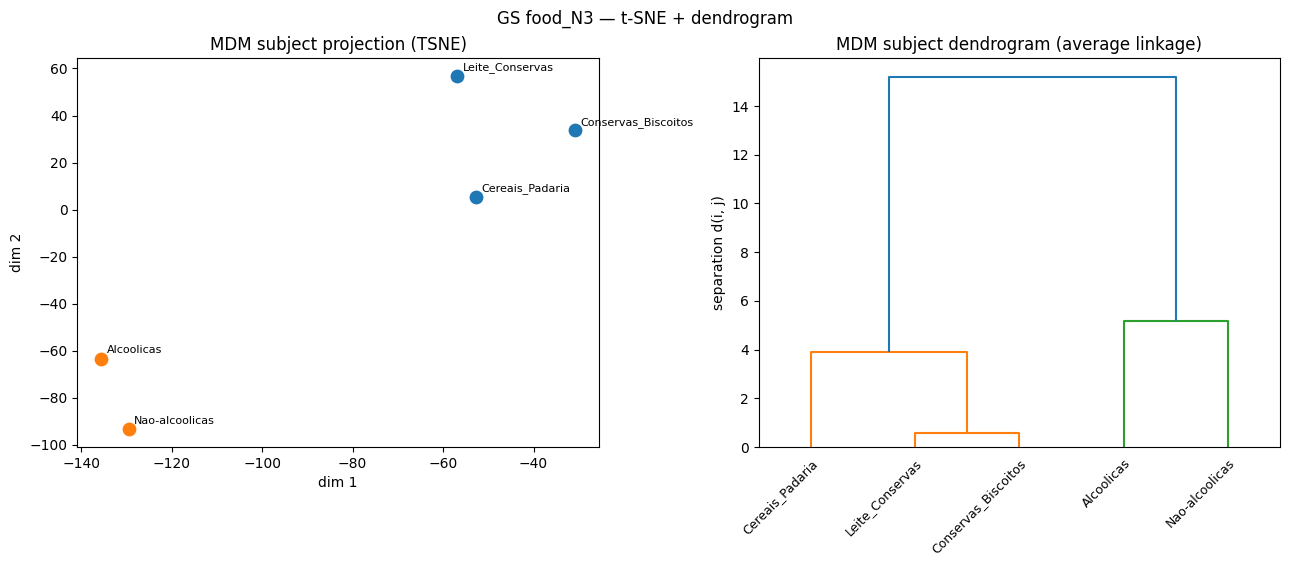

clusters: {'Alcoolicas': 2, 'Nao-alcoolicas': 2, 'Cereais_Padaria': 1, 'Leite_Conservas': 1, 'Conservas_Biscoitos': 1}
nearest neighbours (k=2):
  Alcoolicas: [('Nao-alcoolicas', 5.178510627669311), ('Cereais_Padaria', 10.10677233059323)]
  Nao-alcoolicas: [('Alcoolicas', 5.178510627669311), ('Cereais_Padaria', 16.216312568520152)]
  Cereais_Padaria: [('Conservas_Biscoitos', 2.0126368564133372), ('Leite_Conservas', 5.806856010388856)]
  Leite_Conservas: [('Conservas_Biscoitos', 0.5674067624277086), ('Cereais_Padaria', 5.806856010388856)]
  Conservas_Biscoitos: [('Leite_Conservas', 0.5674067624277086), ('Cereais_Padaria', 2.0126368564133372)]


In [12]:
individuals_f = fit_individual_structures(
    subjects_f,
    method="hc",
    nbf=NBF,
    node_names=node_names_f,
    subject_ids=subject_ids_f,
    n_jobs=-1,
    verbose=False,
)
dist_f = compute_mdm_distance(
    individuals_f,
    metric="lpl_separation",
    nbf=NBF,
    node_names=node_names_f,
    subject_ids=subject_ids_f,
    verbose=False,
)

D = np.asarray(dist_f.matrix, dtype=float)
iu = np.triu_indices_from(D, k=1)
vals = D[iu]
print(
    f"food_N3 distances: min={vals.min():.3f}, max={vals.max():.3f}, "
    f"mean={vals.mean():.3f}, CV={vals.std() / vals.mean():.3f}"
)

fig = plot_group_embedding(dist_f, technique="tsne", n_clusters=2, random_state=0)
plt.suptitle("GS food_N3 — t-SNE + dendrogram", y=1.02)
plt.show()

labels_f = suggest_clusters(dist_f, max_clusters=4)
print("clusters:", dict(zip(subject_ids_f, labels_f.tolist())))
print("nearest neighbours (k=2):")
for sid in subject_ids_f:
    print(f"  {sid}: {nearest_neighbours(dist_f, subject=sid, k=2)}")

## 8. GS — products via lags (`products_N3`)

One subject per SKU. Each series becomes a 3-column lag panel
`[y_t, y_{t-1}, y_{t-2}]` so all products share N=3 for GS (same idea as
`gs_embedding_products_N3_tsne`).

{'n_subjects': 15, 'n_nodes': 3, 'node_names': ['lag0', 'lag1', 'lag2'], 'subject_ids': ['Beer-can', 'Beer-large', 'Beer-ret', 'Rice', 'Beans', 'Bread', 'Soy oil', 'Tomato', 'Milk', 'Yogurt', 'Soda-1.5L', 'Soda-can', 'Juice', 'Cereal bar', 'Chocolate'], 'T_per_subject': [178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178, 178], 'T_min': 178, 'T_max': 178, 'shapes': [(178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3), (178, 3)]}


D:\dev\phd\articles\mdmp-package\mdmp\mdmp\group_analysis\distance\metrics.py:76: UserWarning: lpl_separation: d=-5.293 < 0 (possível inconsistência de score/busca; M_i deveria ser ótimo para i).
  warnings.warn(


D:\dev\phd\articles\mdmp-package\mdmp\mdmp\group_analysis\distance\metrics.py:76: UserWarning: lpl_separation: d=-7.423 < 0 (possível inconsistência de score/busca; M_i deveria ser ótimo para i).
  warnings.warn(


D:\dev\phd\articles\mdmp-package\mdmp\mdmp\group_analysis\distance\metrics.py:76: UserWarning: lpl_separation: d=-5.293 < 0 (possível inconsistência de score/busca; M_i deveria ser ótimo para i).
  warnings.warn(


D:\dev\phd\articles\mdmp-package\mdmp\mdmp\group_analysis\distance\metrics.py:76: UserWarning: lpl_separation: d=-7.423 < 0 (possível inconsistência de score/busca; M_i deveria ser ótimo para i).
  warnings.warn(


...

D:\dev\phd\articles\mdmp-package\mdmp\mdmp\group_analysis\distance\metrics.py:76: UserWarning: lpl_separation: d=-10.01 < 0 (possível inconsistência de score/busca; M_i deveria ser ótimo para i).
  warnings.warn(


D:\dev\phd\articles\mdmp-package\mdmp\mdmp\group_analysis\distance\metrics.py:76: UserWarning: lpl_separation: d=-3.905 < 0 (possível inconsistência de score/busca; M_i deveria ser ótimo para i).
  warnings.warn(


D:\dev\phd\articles\mdmp-package\mdmp\mdmp\group_analysis\distance\metrics.py:76: UserWarning: lpl_separation: d=-20.35 < 0 (possível inconsistência de score/busca; M_i deveria ser ótimo para i).
  warnings.warn(


D:\dev\phd\articles\mdmp-package\mdmp\mdmp\group_analysis\distance\metrics.py:76: UserWarning: lpl_separation: d=-11.54 < 0 (possível inconsistência de score/busca; M_i deveria ser ótimo para i).
  warnings.warn(


products_N3 distances: min=0.000, max=32.068, mean=3.259, CV=1.982


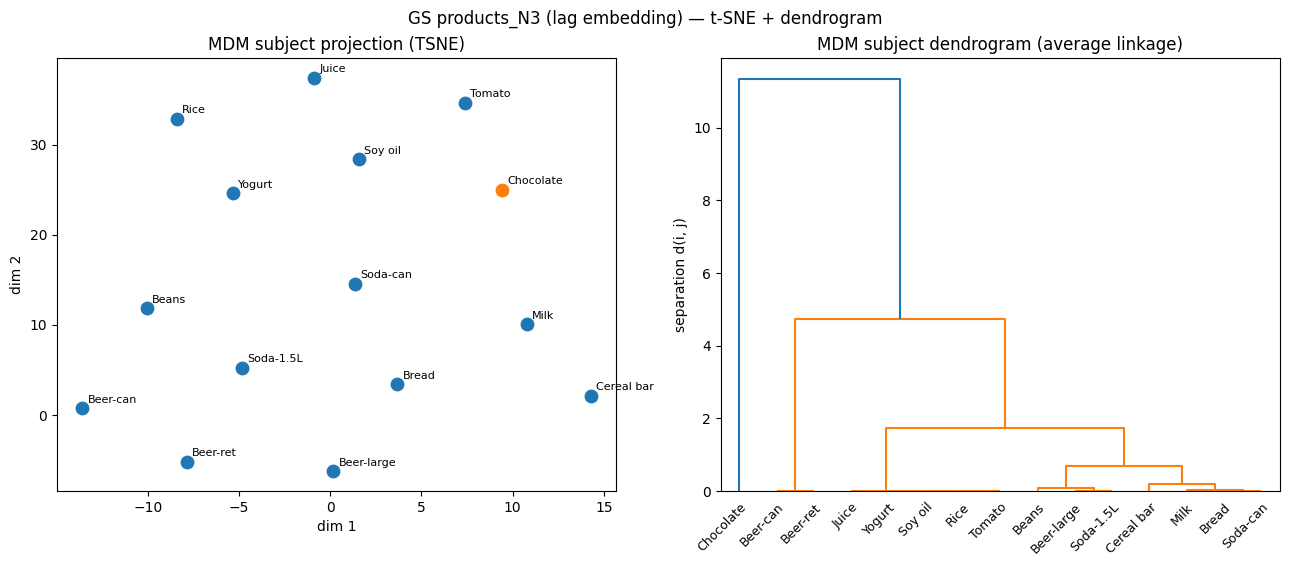

clusters: {'Beer-can': 1, 'Beer-large': 1, 'Beer-ret': 1, 'Rice': 1, 'Beans': 1, 'Bread': 1, 'Soy oil': 1, 'Tomato': 1, 'Milk': 1, 'Yogurt': 1, 'Soda-1.5L': 1, 'Soda-can': 1, 'Juice': 1, 'Cereal bar': 1, 'Chocolate': 2}
nearest neighbours (k=2) — first 5 SKUs:
  Beer-can: [('Beer-ret', 0.0), ('Soda-1.5L', 0.0)]
  Beer-large: [('Beer-ret', 0.0), ('Soda-1.5L', 0.0)]
  Beer-ret: [('Beer-can', 0.0), ('Beer-large', 0.0)]
  Rice: [('Soy oil', 0.0), ('Tomato', 0.0)]
  Beans: [('Soda-1.5L', 0.0), ('Soda-can', 0.0)]


In [13]:
short_ids = [SKU_DAG_LABELS.get(s, s) for s in skus]
subjects_p, subject_ids_p, node_names_p = product_lag_subjects(
    sales, n_lags=3, subject_ids=short_ids
)
print(cohort_summary(subjects_p, subject_ids_p, node_names_p))

individuals_p = fit_individual_structures(
    subjects_p,
    method="hc",
    nbf=NBF,
    node_names=node_names_p,
    subject_ids=subject_ids_p,
    n_jobs=-1,
    verbose=False,
)
dist_p = compute_mdm_distance(
    individuals_p,
    metric="lpl_separation",
    nbf=NBF,
    node_names=node_names_p,
    subject_ids=subject_ids_p,
    verbose=False,
)

D = np.asarray(dist_p.matrix, dtype=float)
iu = np.triu_indices_from(D, k=1)
vals = D[iu]
print(
    f"products_N3 distances: min={vals.min():.3f}, max={vals.max():.3f}, "
    f"mean={vals.mean():.3f}, CV={vals.std() / vals.mean():.3f}"
)

fig = plot_group_embedding(dist_p, technique="tsne", n_clusters=2, random_state=0)
plt.suptitle("GS products_N3 (lag embedding) — t-SNE + dendrogram", y=1.02)
plt.show()

labels_p = suggest_clusters(dist_p, max_clusters=4)
print("clusters:", dict(zip(subject_ids_p, labels_p.tolist())))
print("nearest neighbours (k=2) — first 5 SKUs:")
for sid in subject_ids_p[:5]:
    print(f"  {sid}: {nearest_neighbours(dist_p, subject=sid, k=2)}")

## 9. Takeaways

| Goal | Cohort | Why |
| --- | --- | --- |
| Product structure / anomalies | 15 SKUs | Full multivariate panel |
| Hierarchy DAGs | C3 / C4 sums | Coarser product-line / type graph |
| **IS / VTS** | **Monthly, shared N=7** | Same node semantics across "individuals" |
| **GS food** | Food groups N=3 | Equal N, category-level distance |
| **GS products** | Lag panels N=3 | Equal N per SKU without cross-SKU aggregation |

```python
# APIs exercised: 
- MDM()
- detect_anomalies()
- plot_anomalies()
- plot_dag(style="graphviz")
- fit_individual_structures()
- compute_vts()
- aggregate_individual_structures()
- compute_mdm_distance()
- plot_group_embedding()
- suggest_clusters
- nearest_neighbours()
```